# TT-05 — SVM: Phân loại khối u lành tính / ác tính



## Bước 0 — Cài thư viện 

In [32]:
%pip install scikit-learn pandas matplotlib seaborn joblib

Note: you may need to restart the kernel to use updated packages.


In [33]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, recall_score, precision_score,
    ConfusionMatrixDisplay, make_scorer
)

# Notebook nằm trong notebooks/ -> lùi ra 1 cấp để về thư mục gốc project
os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

print("Thư mục làm việc hiện tại:", os.getcwd())


Thư mục làm việc hiện tại: d:\TT_ML\TT-05-SVM_Linh\notebooks


## Bước 1 — Nạp dữ liệu, xác nhận quy ước nhãn (0 = ác tính!)

In [34]:
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

print("Kích thước X:", X.shape)
print("Tên nhãn (target_names):", data.target_names)
print("\nPhân bố nhãn:")
print(y.value_counts())


Kích thước X: (569, 30)
Tên nhãn (target_names): ['malignant' 'benign']

Phân bố nhãn:
target
1    357
0    212
Name: count, dtype: int64


### Kiểm tra thêm thông tin dataset

In [35]:
print("Kiểu dữ liệu từng cột:")
print(X.dtypes.value_counts())

print("\nSố giá trị thiếu (NaN):", X.isnull().sum().sum())

print("\nThống kê mô tả (mean, std, min, max):")
X.describe().T[["mean", "std", "min", "max"]]


Kiểu dữ liệu từng cột:
float64    30
Name: count, dtype: int64

Số giá trị thiếu (NaN): 0

Thống kê mô tả (mean, std, min, max):


,mean,std,min,max
mean radius,14.127292,3.524049,6.981000,28.11000
mean texture,19.289649,4.301036,9.710000,39.28000
mean perimeter,91.969033,24.298981,43.790000,188.50000
mean area,654.889104,351.914129,143.500000,2501.00000
mean smoothness,0.096360,0.014064,0.052630,0.16340
mean compactness,0.104341,0.052813,0.019380,0.34540
mean concavity,0.088799,0.079720,0.000000,0.42680
mean concave points,0.048919,0.038803,0.000000,0.20120
mean symmetry,0.181162,0.027414,0.106000,0.30400
mean fractal dimension,0.062798,0.007060,0.049960,0.09744


## Bước 2 — EDA: heatmap tương quan 30 biến

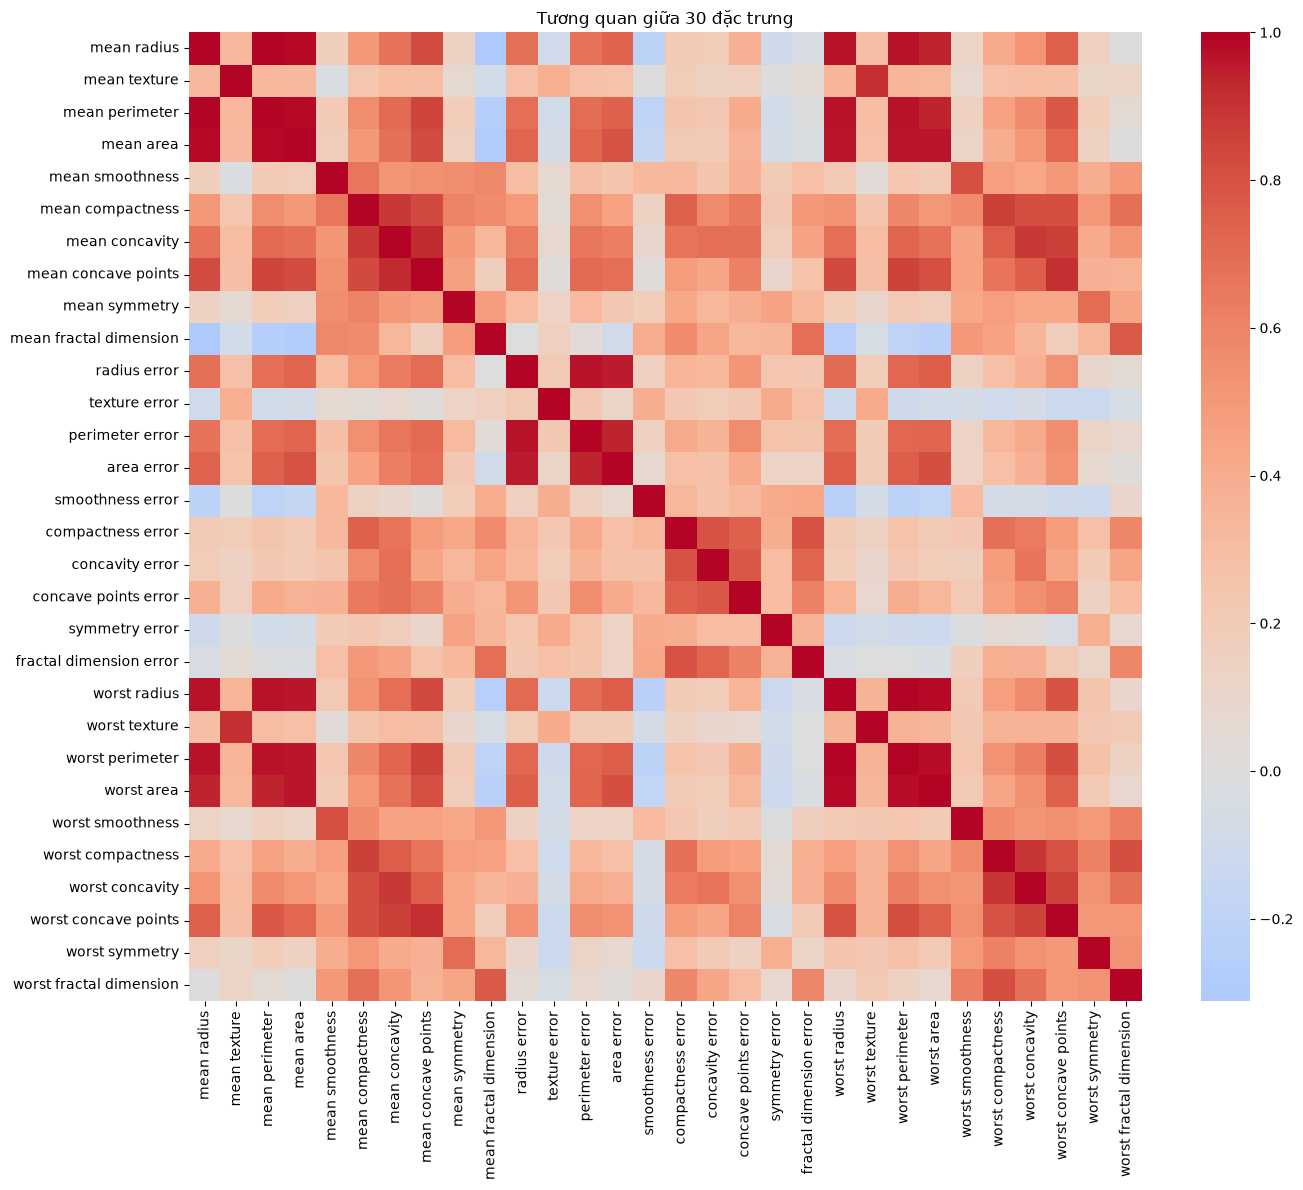

In [36]:
plt.figure(figsize=(14, 12))
sns.heatmap(X.corr(), cmap="coolwarm", center=0)
plt.title("Tương quan giữa 30 đặc trưng")
plt.tight_layout()
plt.savefig("../reports/correlation_heatmap.png")
plt.show()


## Bước 3 — Chia train/test stratify


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (455, 30) | Test: (114, 30)


## Bước 4 — SVM KHÔNG scale (baseline)

In [38]:
svm_noscale = SVC(random_state=42)
svm_noscale.fit(X_train, y_train)
pred_noscale = svm_noscale.predict(X_test)

print(classification_report(y_test, pred_noscale, target_names=data.target_names))

recall_noscale = recall_score(y_test, pred_noscale, pos_label=0)
print(f"Recall lớp ÁC TÍNH (không scale): {recall_noscale:.3f}")


              precision    recall  f1-score   support

   malignant       0.95      0.86      0.90        42
      benign       0.92      0.97      0.95        72

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114

Recall lớp ÁC TÍNH (không scale): 0.857


## Bước 5 — SVM CÓ scale (Pipeline) 


In [39]:
pipe = Pipeline([
    ("scale", StandardScaler()),
    ("svm", SVC(class_weight="balanced", random_state=42)),
])
pipe.fit(X_train, y_train)
pred_scaled = pipe.predict(X_test)

print(classification_report(y_test, pred_scaled, target_names=data.target_names))

recall_scaled = recall_score(y_test, pred_scaled, pos_label=0)
print(f"Recall lớp ÁC TÍNH (có scale): {recall_scaled:.3f}")


              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114

Recall lớp ÁC TÍNH (có scale): 0.976


### Bảng + biểu đồ so sánh CÓ vs KHÔNG scale

                  Không scale  Có scale
Recall (ác tính)     0.857143   0.97619


<Figure size 500x400 with 0 Axes>

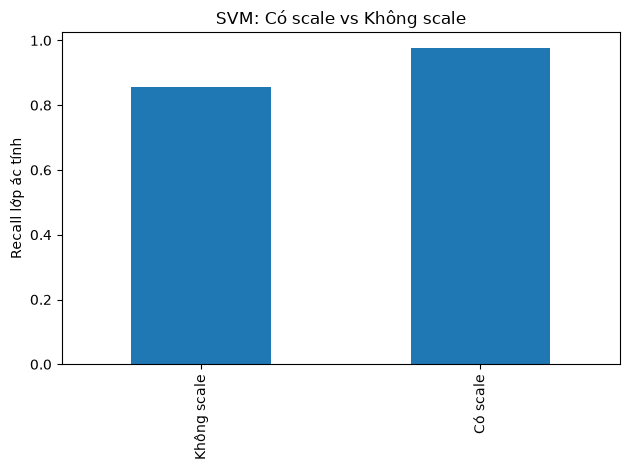

In [40]:
compare_scale = pd.DataFrame({
    "Không scale": [recall_noscale],
    "Có scale": [recall_scaled],
}, index=["Recall (ác tính)"])
print(compare_scale)

plt.figure(figsize=(5, 4))
compare_scale.T.plot(kind="bar", legend=False)
plt.ylabel("Recall lớp ác tính")
plt.title("SVM: Có scale vs Không scale")
plt.tight_layout()
plt.savefig("../reports/scale_vs_noscale.png")
plt.show()


## Bước 6 — So sánh 3 kernel (cùng C=1)

linear    0.976190
rbf       0.976190
poly      0.904762
Name: Recall (ác tính), dtype: float64


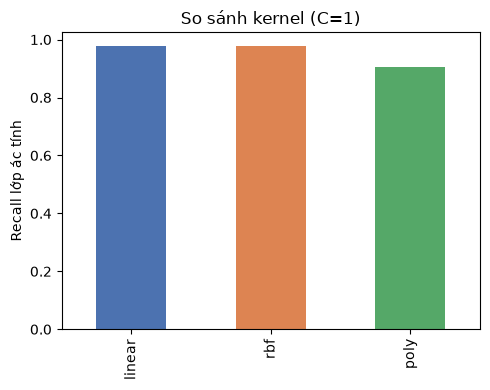

In [41]:
kernel_results = {}
for kernel in ["linear", "rbf", "poly"]:
    p = Pipeline([
        ("scale", StandardScaler()),
        ("svm", SVC(kernel=kernel, C=1, class_weight="balanced", random_state=42)),
    ])
    p.fit(X_train, y_train)
    pred = p.predict(X_test)
    kernel_results[kernel] = recall_score(y_test, pred, pos_label=0)

kernel_df = pd.Series(kernel_results, name="Recall (ác tính)")
print(kernel_df)

plt.figure(figsize=(5, 4))
kernel_df.plot(kind="bar", color=["#4C72B0", "#DD8452", "#55A868"])
plt.ylabel("Recall lớp ác tính")
plt.title("So sánh kernel (C=1)")
plt.tight_layout()
plt.savefig("../reports/kernel_comparison.png")
plt.show()


## Bước 7 — GridSearchCV dò C, gamma, kernel


In [42]:
recall_malignant_scorer = make_scorer(recall_score, pos_label=0)

grid = {
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", 0.001, 0.01, 0.1],
    "svm__kernel": ["linear", "rbf", "poly"],
}

gs = GridSearchCV(pipe, grid, cv=5, scoring=recall_malignant_scorer, n_jobs=-1)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV recall (ác tính):", round(gs.best_score_, 4))


Best params: {'svm__C': 1, 'svm__gamma': 0.1, 'svm__kernel': 'rbf'}
Best CV recall (ác tính): 0.9765


## Bước 8 — Heatmap điểm CV theo (C, gamma) 


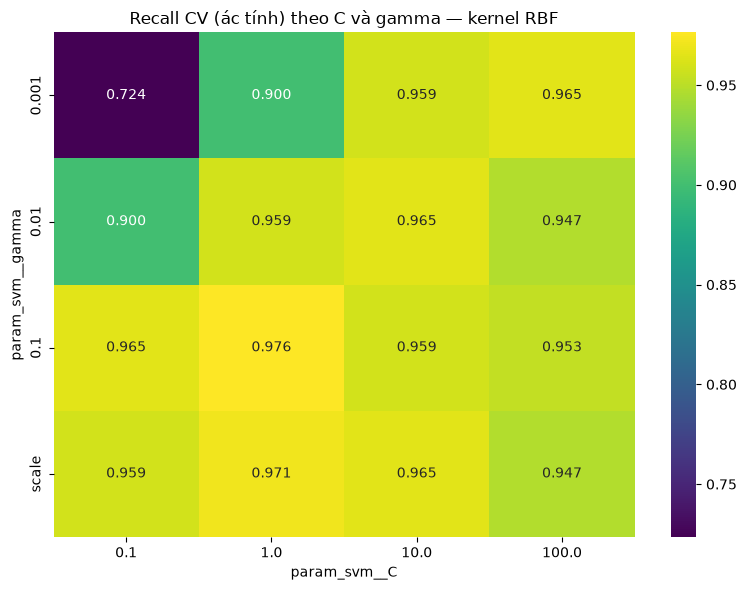

In [43]:
cv_results = pd.DataFrame(gs.cv_results_)
rbf_results = cv_results[cv_results["param_svm__kernel"] == "rbf"]

pivot = rbf_results.pivot_table(
    index="param_svm__gamma", columns="param_svm__C", values="mean_test_score"
)

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis")
plt.title("Recall CV (ác tính) theo C và gamma — kernel RBF")
plt.tight_layout()
plt.savefig("../reports/C_gamma_heatmap.png")
plt.show()


## Bước 9 — Đếm support vectors

In [44]:
best_svm = gs.best_estimator_.named_steps["svm"]
n_sv = best_svm.n_support_
pct_sv = n_sv.sum() / len(X_train) * 100

print(f"Support vectors mỗi lớp: {n_sv}")
print(f"Tổng support vectors: {n_sv.sum()} / {len(X_train)} ({pct_sv:.1f}%)")


Support vectors mỗi lớp: [94 90]
Tổng support vectors: 184 / 455 (40.4%)


## Bước 10 — Chọn ngưỡng để recall ác tính ≥ 0.98

In [45]:
best_params_clean = {k.replace("svm__", ""): v for k, v in gs.best_params_.items()}

pipe_proba = Pipeline([
    ("scale", StandardScaler()),
    ("svm", SVC(**best_params_clean, probability=True,
                class_weight="balanced", random_state=42)),
])
pipe_proba.fit(X_train, y_train)

# proba[:, 0] = xác suất thuộc lớp 0 (ác tính)
proba_malignant = pipe_proba.predict_proba(X_test)[:, 0]

threshold_results = []
chosen_threshold = None
for threshold in np.arange(0.05, 0.55, 0.05):
    pred_thresh = np.where(proba_malignant >= threshold, 0, 1)
    r = recall_score(y_test, pred_thresh, pos_label=0)
    p = precision_score(y_test, pred_thresh, pos_label=0)
    threshold_results.append((round(threshold, 2), r, p))
    if r >= 0.98 and chosen_threshold is None:
        chosen_threshold = threshold

threshold_df = pd.DataFrame(threshold_results, columns=["threshold", "recall", "precision"])
print(threshold_df)

if chosen_threshold is None:
    chosen_threshold = threshold_df["threshold"].min()
    print("\nCẢNH BÁO: không tìm được threshold đạt recall >= 0.98 trong khoảng quét,"
          " dùng threshold nhỏ nhất đã thử.")
else:
    r_chosen = threshold_df.loc[threshold_df.threshold == round(chosen_threshold, 2), "recall"].values[0]
    print(f"\n-> Chọn threshold = {chosen_threshold:.2f} (recall ác tính = {r_chosen:.3f})")


   threshold    recall  precision
0       0.05  1.000000   0.711864
1       0.10  0.976190   0.773585
2       0.15  0.976190   0.788462
3       0.20  0.976190   0.820000
4       0.25  0.976190   0.854167
5       0.30  0.976190   0.854167
6       0.35  0.976190   0.854167
7       0.40  0.976190   0.872340
8       0.45  0.952381   0.888889
9       0.50  0.952381   0.909091

-> Chọn threshold = 0.05 (recall ác tính = 1.000)


c:\Users\lenovo\miniconda3\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


## Bước 11 — Ma trận nhầm lẫn 

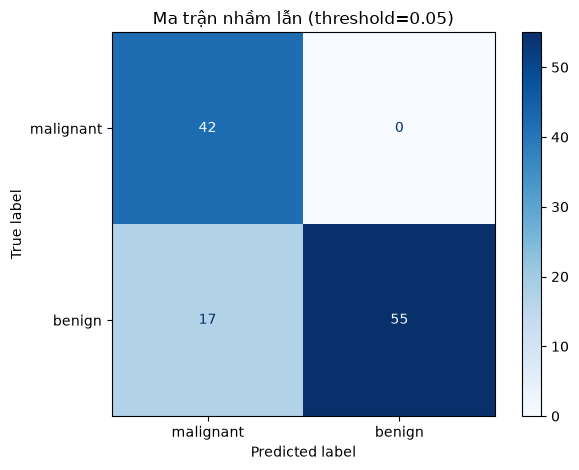

Số ca ÁC TÍNH bị bỏ sót: 0


In [46]:
pred_final = np.where(proba_malignant >= chosen_threshold, 0, 1)

cm_disp = ConfusionMatrixDisplay.from_predictions(
    y_test, pred_final, display_labels=data.target_names, cmap="Blues"
)
plt.title(f"Ma trận nhầm lẫn (threshold={chosen_threshold:.2f})")
plt.tight_layout()
plt.savefig("../reports/confusion_matrix.png")
plt.show()

cm = cm_disp.confusion_matrix
missed_malignant = cm[0, 1]  # thực tế ác tính (0), dự đoán lành tính (1)
print(f"Số ca ÁC TÍNH bị bỏ sót: {missed_malignant}")


## Bước 12 — So sánh với Logistic Regression (TT-04)

In [47]:
logreg = Pipeline([
    ("scale", StandardScaler()),
    ("lr", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)),
])
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
recall_lr = recall_score(y_test, pred_lr, pos_label=0)

recall_svm_final = recall_score(y_test, pred_final, pos_label=0)

print(f"Logistic Regression - recall (ác tính): {recall_lr:.3f}")
print(f"SVM (đã chỉnh ngưỡng)  - recall (ác tính): {recall_svm_final:.3f}")


Logistic Regression - recall (ác tính): 0.976
SVM (đã chỉnh ngưỡng)  - recall (ác tính): 1.000


## Lưu model cuối cùng

In [48]:
joblib.dump(gs.best_estimator_, "../models/svm_pipeline.joblib")
print("Đã lưu models/svm_pipeline.joblib")


Đã lưu models/svm_pipeline.joblib
